# Time Series Analysis

This notebook demonstrates time series and phenology analysis with `ndvi2gif`, using the `TimeSeriesAnalyzer` and `SpatialTrendAnalyzer` classes: extracting multi-year series from seasonal composites, detecting trends (Mann–Kendall, Sen's slope), and deriving phenological metrics (SOS, POS, EOS) for optical, SAR and climate data.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="geemap.conversion")

In [2]:
import ee
import geemap
import matplotlib.pyplot as plt
from ndvi2gif import NdviSeasonality
from ndvi2gif.timeseries import TimeSeriesAnalyzer, SpatialTrendAnalyzer
print("✓ Modules imported")

# Authenticate & initialize Earth Engine
#ee.Authenticate()
ee.Initialize(project='your-project-id')

✓ Modules imported


In [3]:
# Create interactive map
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [4]:
# Every composite is built over the ROI, so a point outside it returns empty
# periods. Deriving the ROI from the point keeps the two consistent by design.
sites = {
    'delta_del_ebro': (0.838838, 40.705826),    # rice, Ebro delta
    'isla_mayor':     (-6.189970, 37.141442),   # rice, Guadalquivir marshes
    'palencia':       (-5.676501, 42.418859),   # rainfed cereal
    'lebrija':        (-6.063629, 36.985864),   # rice, lower Guadalquivir
    'california':     (-119.422422, 35.643278), # irrigated crops, Central Valley
}

site = 'delta_del_ebro'
point = sites[site]
roi = ee.Geometry.Point(list(point)).buffer(5000)

# To analyse your own area, draw it on the map above and uncomment this line
# (then pick a `point` that falls inside it):
# roi = Map.draw_last_feature.geometry()


There we go again...
Applying cloud filter to Sentinel-2: max 20% cloud cover
Applying pixel-level cloud/shadow mask using SCL band
Sentinel-2 collection configured with cloud filtering
Using point coordinates: (0.838838, 40.705826)


Extracting 60 temporal periods...



Successfully extracted 58 data points
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 319.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 289.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 290.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 289.0
Year 2022: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 289.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 5/5 (100.0%)


Figure saved to rice_comprehensive.png


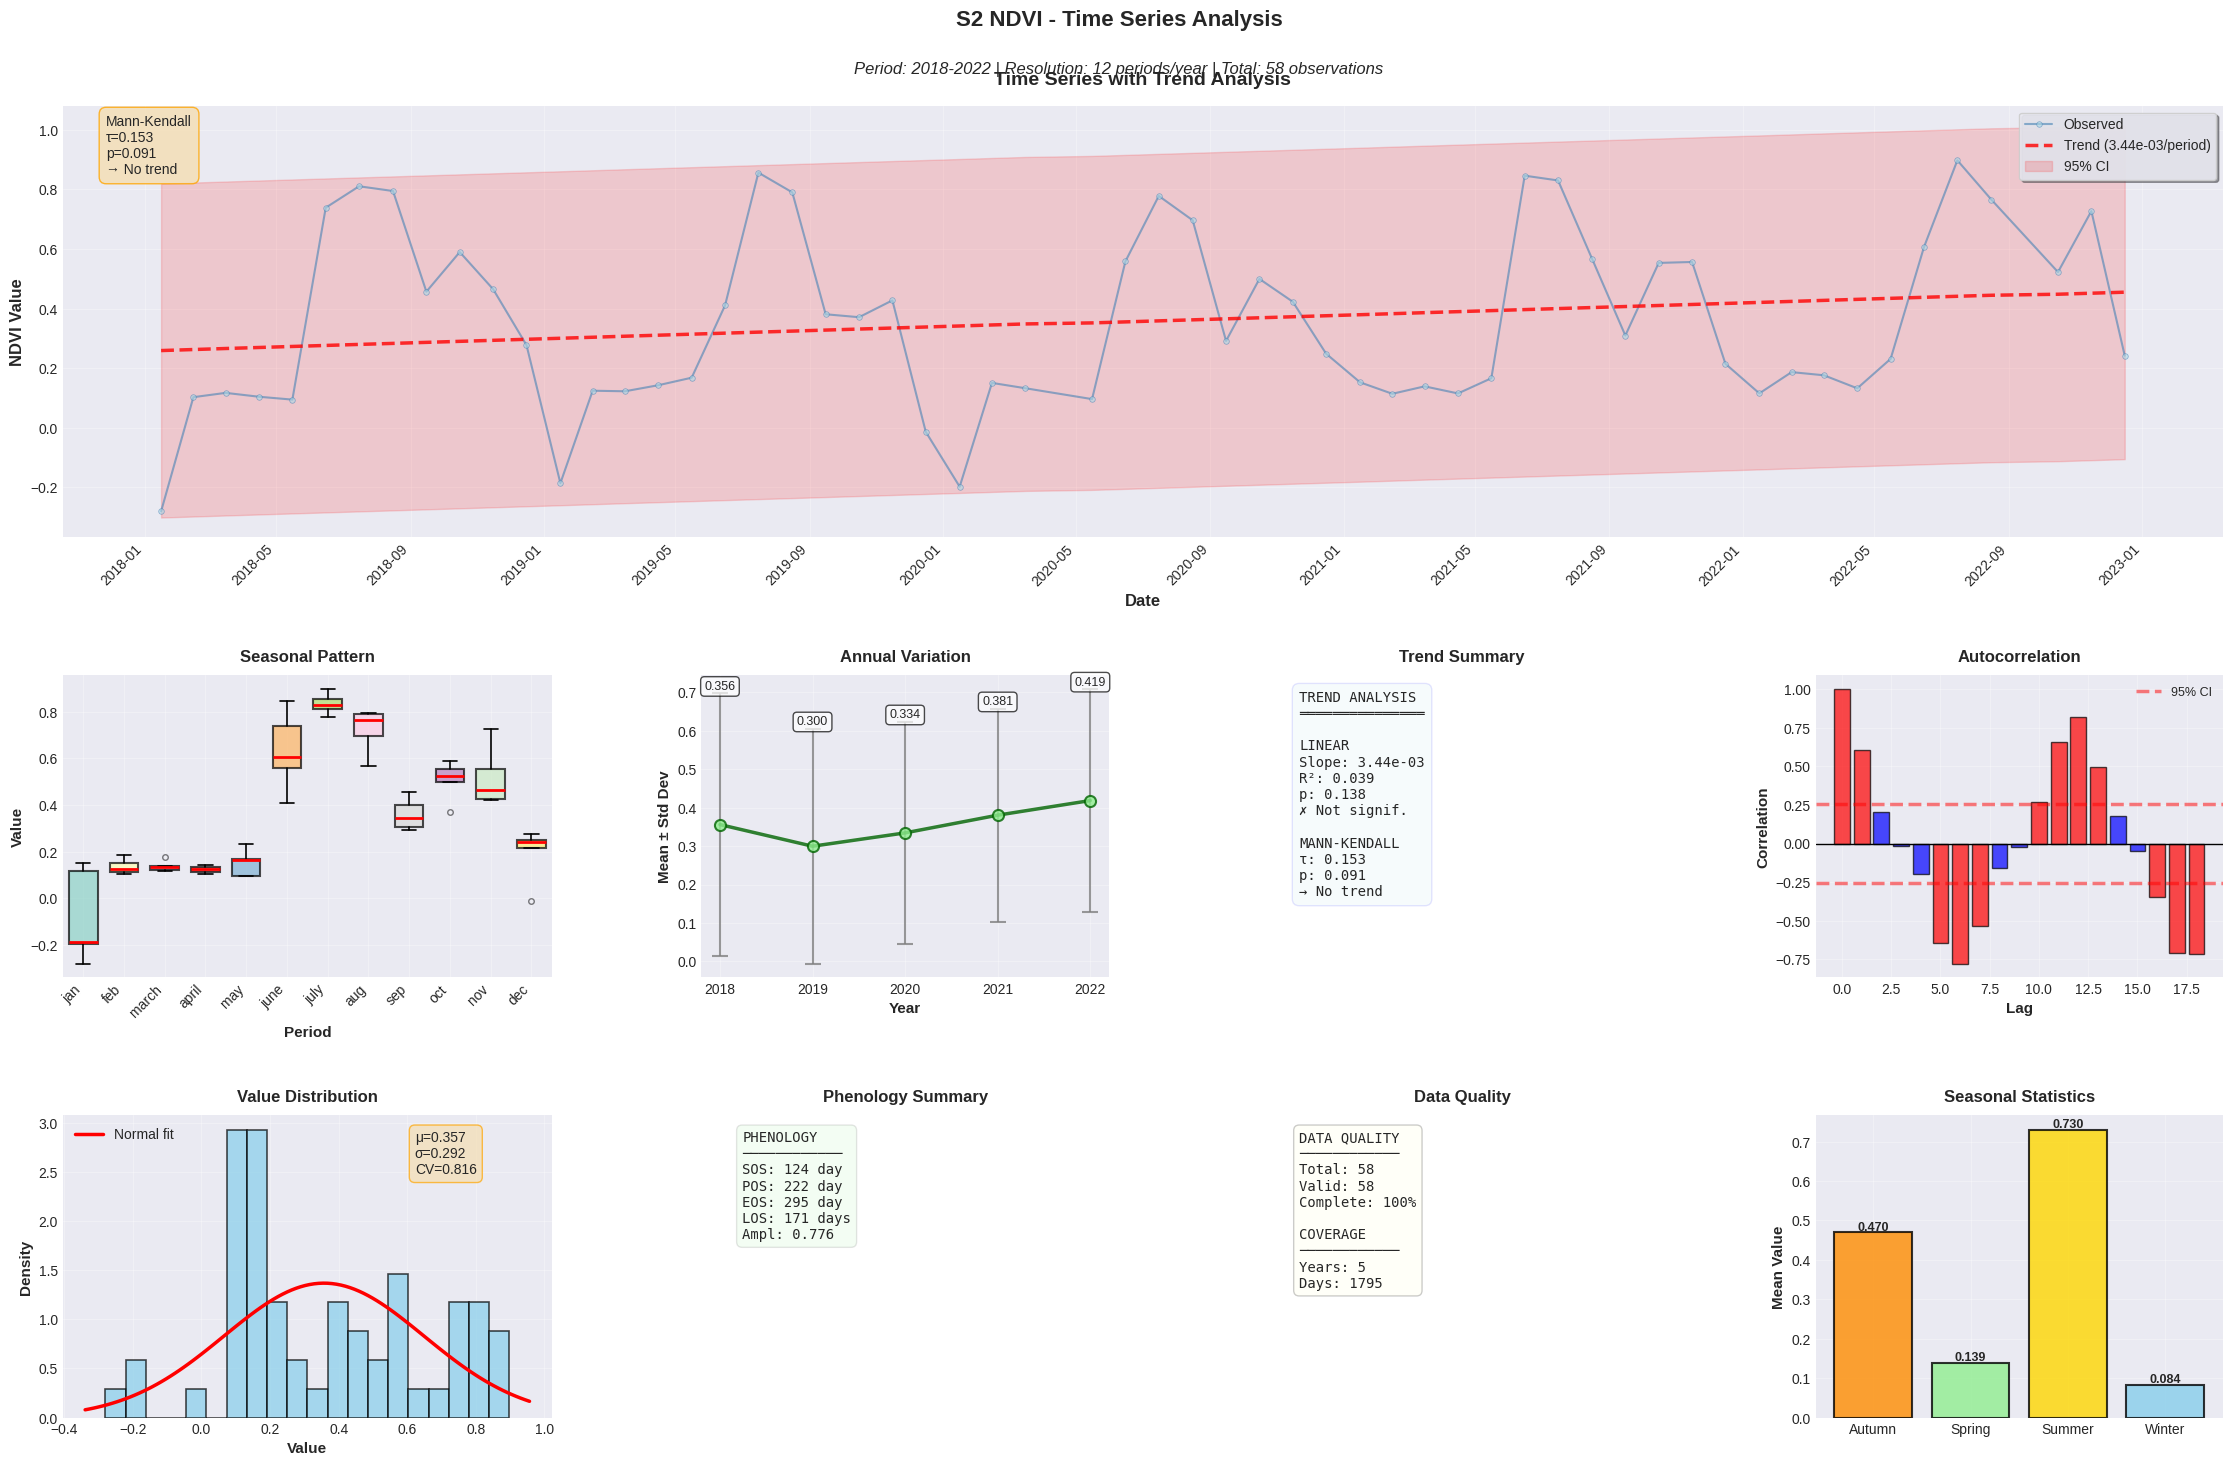

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 350.0
EOS found at day 350.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 320.0
EOS found at day 320.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0
Year 2022: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 5/5 (100.0%)


Phenological analysis saved to rice_phenology_threshold.png


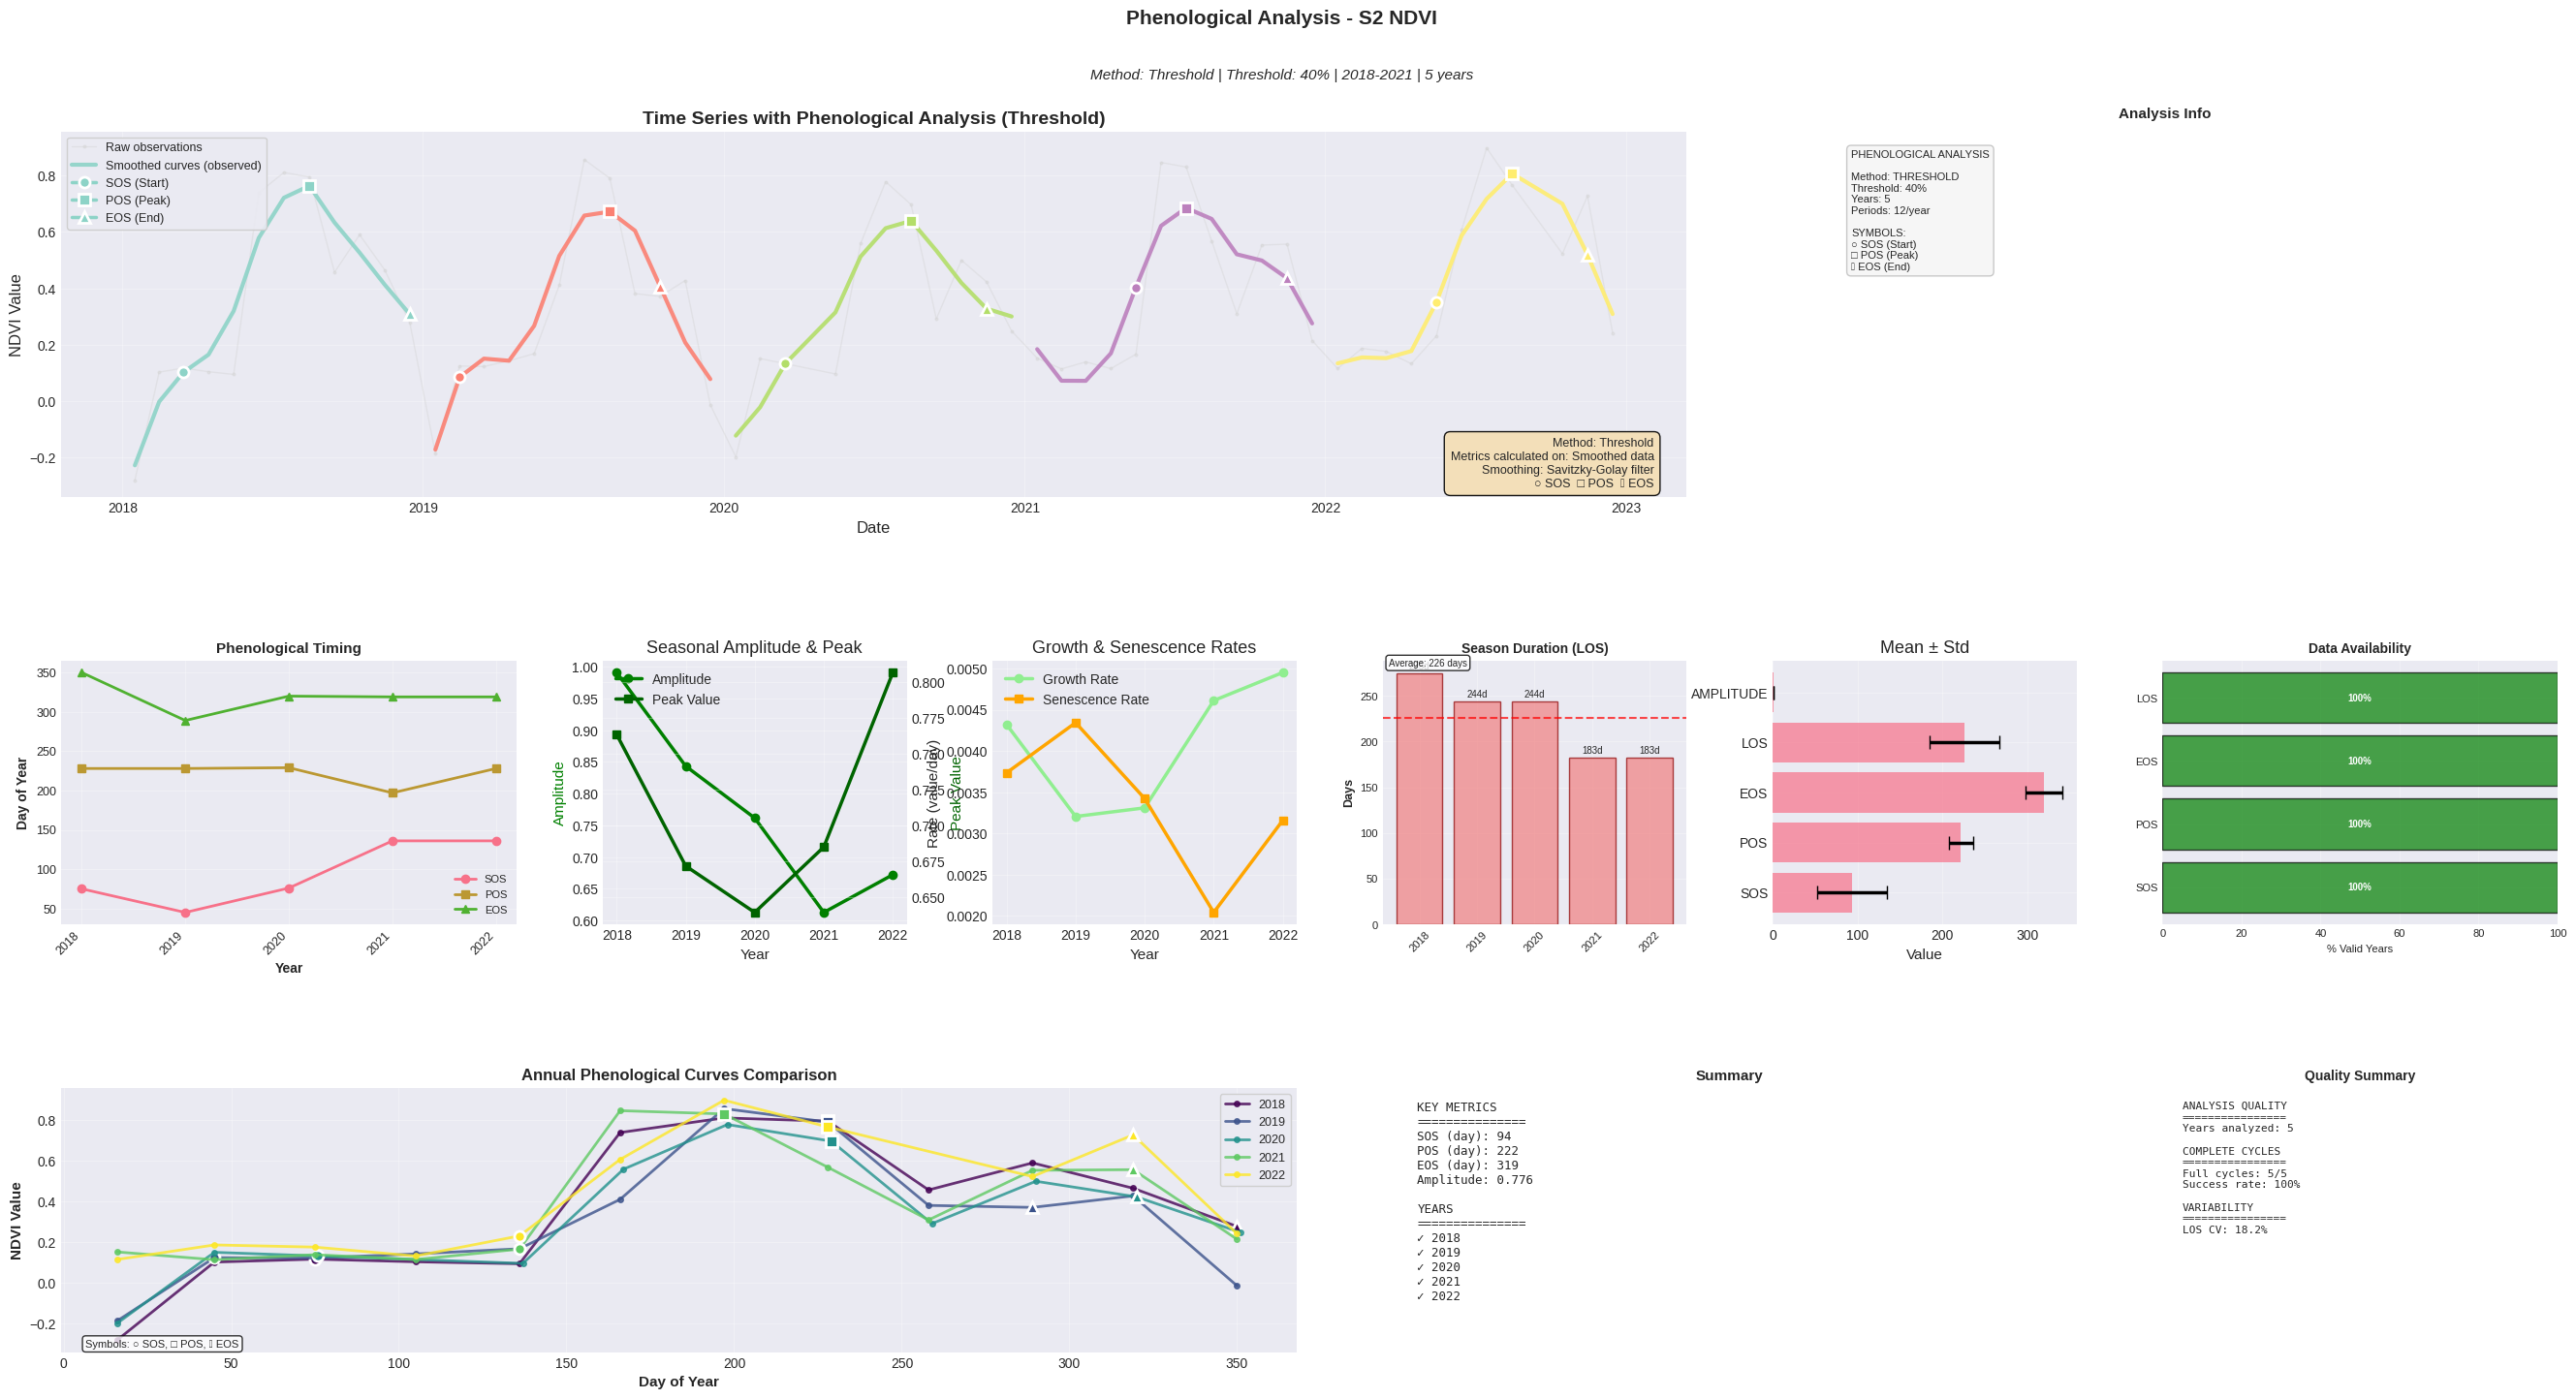

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0015, neg=-0.0011
EOS found at day 258.0, 30.0 days after POS
Year 2019: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0014, neg=-0.0012
EOS found at day 258.0, 30.0 days after POS
Year 2020: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0011, neg=-0.0008
EOS found at day 259.0, 30.0 days after POS
Year 2021: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0010
EOS found at day 228.0, 31.0 days after POS
Year 2022: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0011, neg=-0.0011
EOS found at day 289.0, 61.0 days after POS

PHENOLOGY EXTRACTION SUMMARY:
Method: derivative
Success rate: 5/5 (100.0%)


Phenological analysis saved to rice_phenology_derivative.png


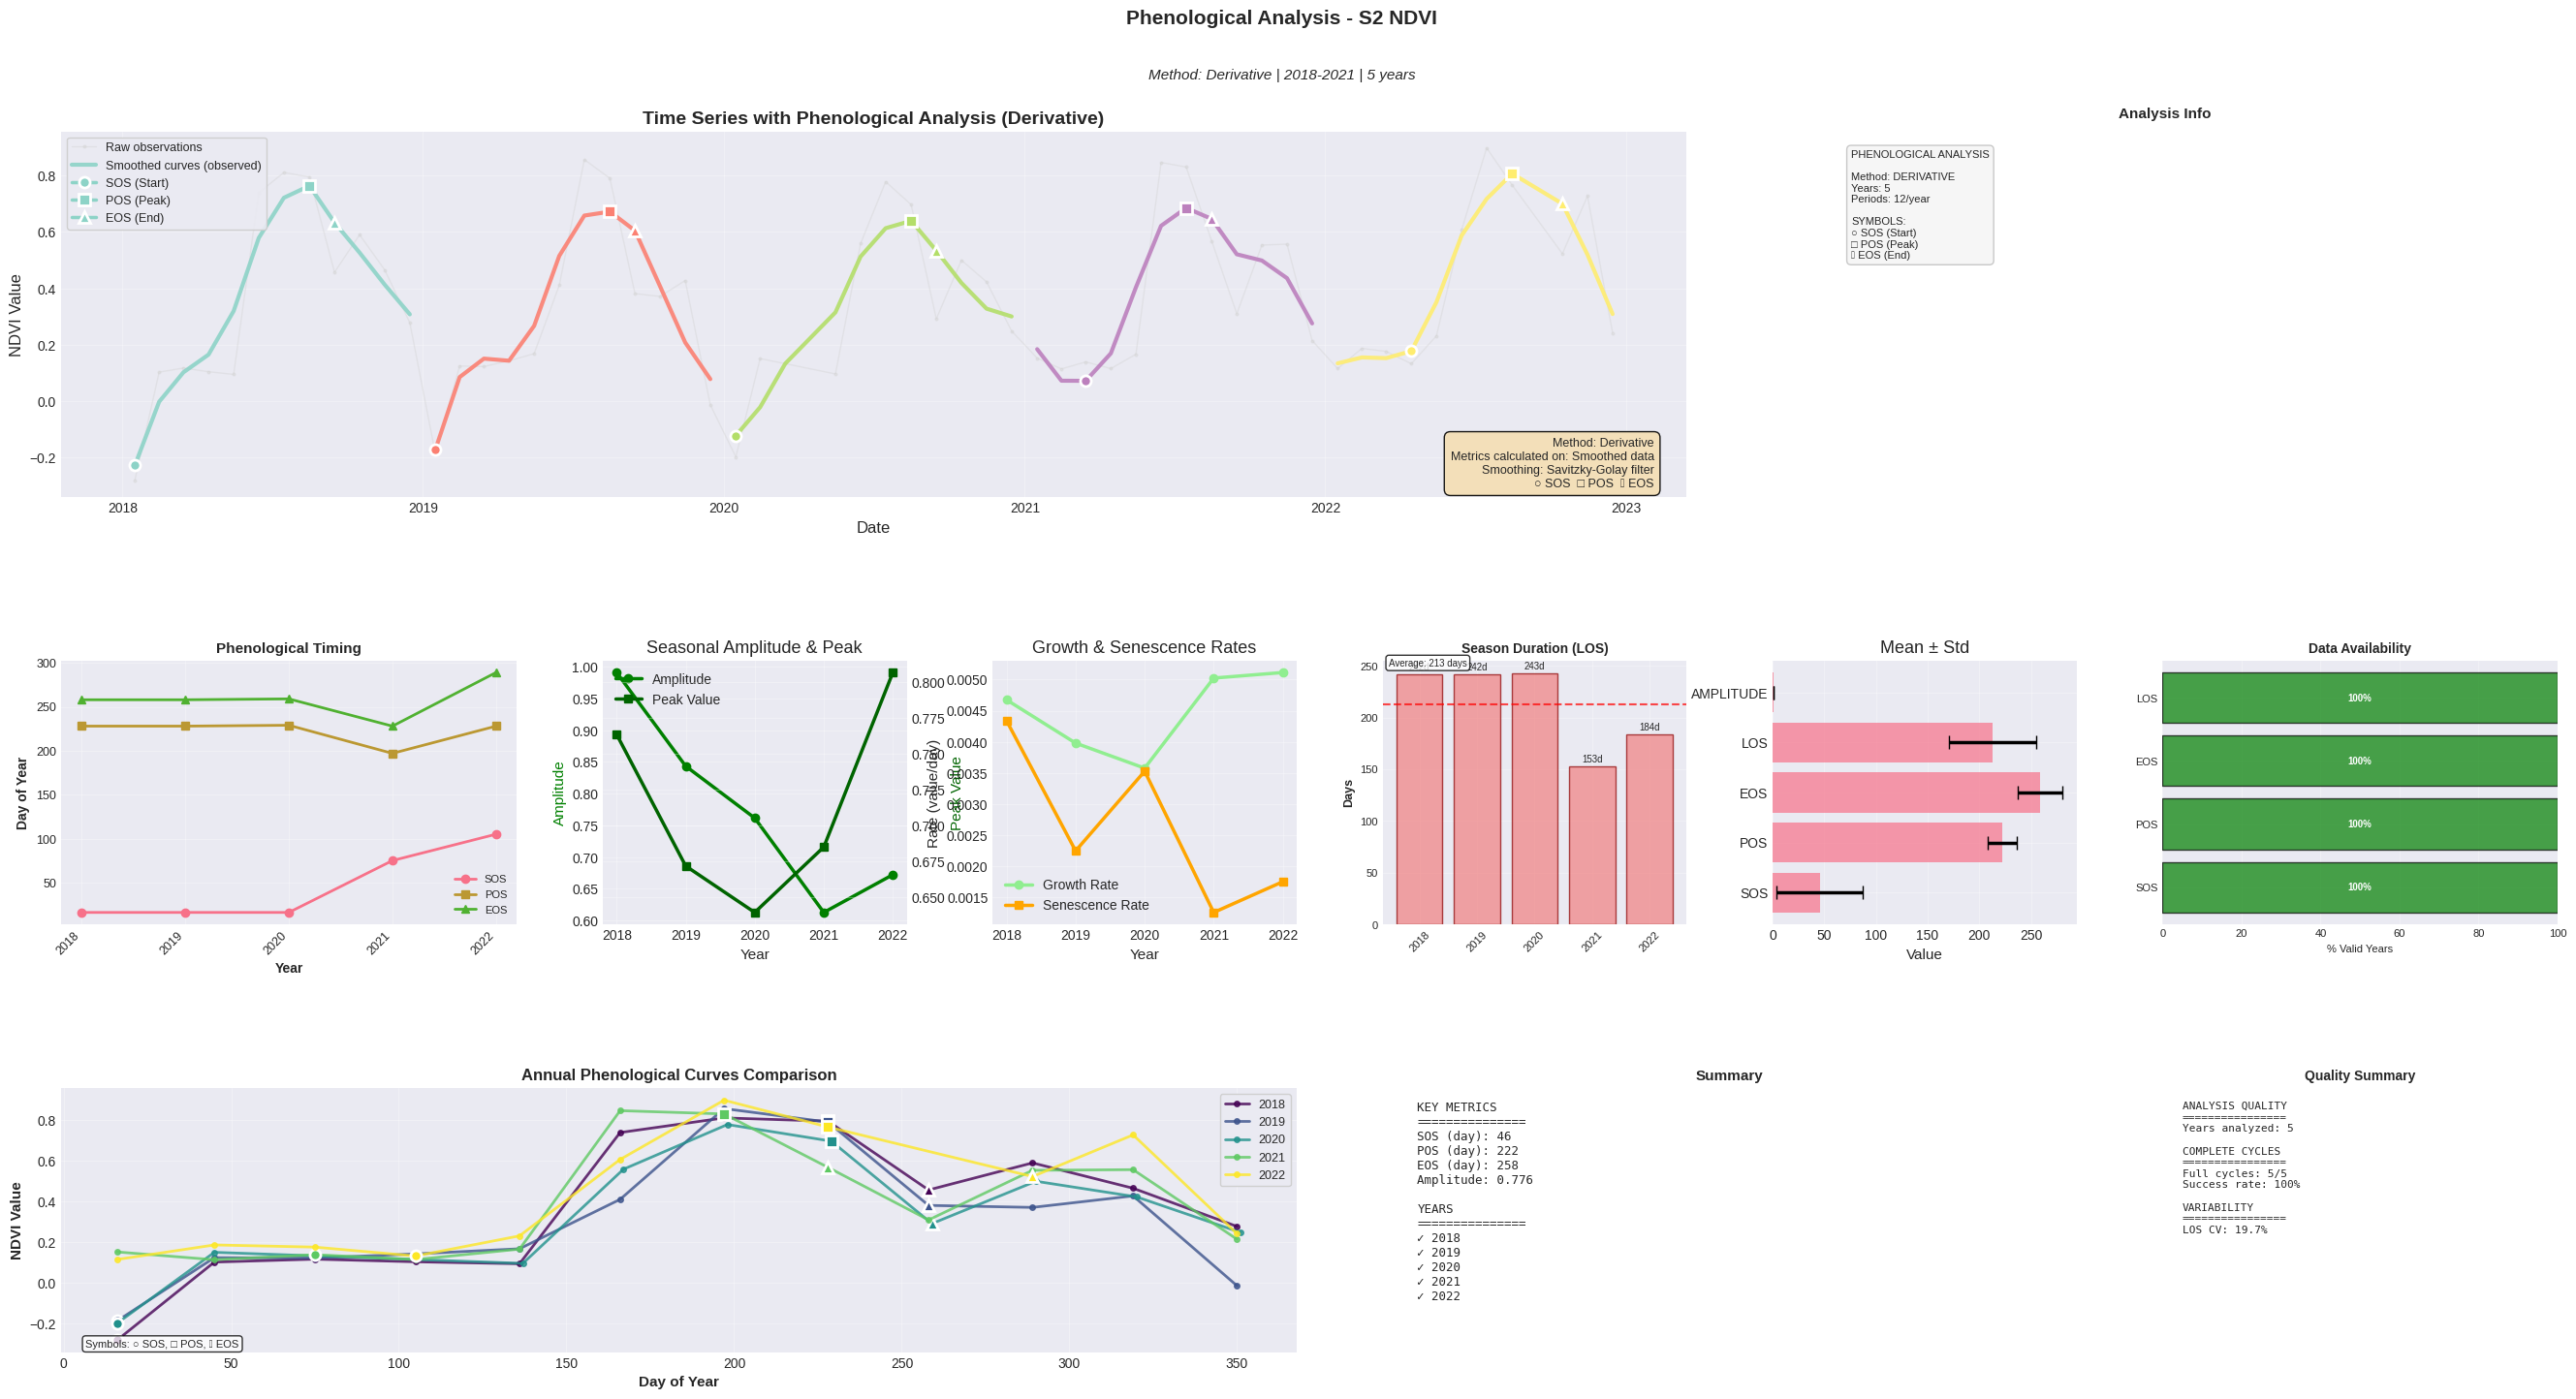

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Logistic fitting failed: Optimal parameters not found: Number of calls to function has reached maxfev = 2000.
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 319.0
Year 2019: Applied smoothing (window=7, order=3)
Logistic fitting failed: Optimal parameters not found: Number of calls to function has reached maxfev = 2000.
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 289.0
Year 2020: Applied smoothing (window=7, order=3)
Logistic fitting failed: Optimal parameters not found: Number of calls to function has reached maxfev = 2000.
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 290.0
Year 2021: Applied smoothing (window=7, order=3)
Logistic fit: R²=0.976, RMSE=0.0329, LOS=74.0 days
Year 2022: Applied smoothing (window=7, order=3)
Logistic fit: R²=0.998, RMSE=0.0121, LOS=171.8 days

PHENOLOGY EXTRACTION SUMMARY:
Method: logistic
Success rate: 5/5 (100.0%)


Phenological analysis saved to rice_phenology_logistic.png


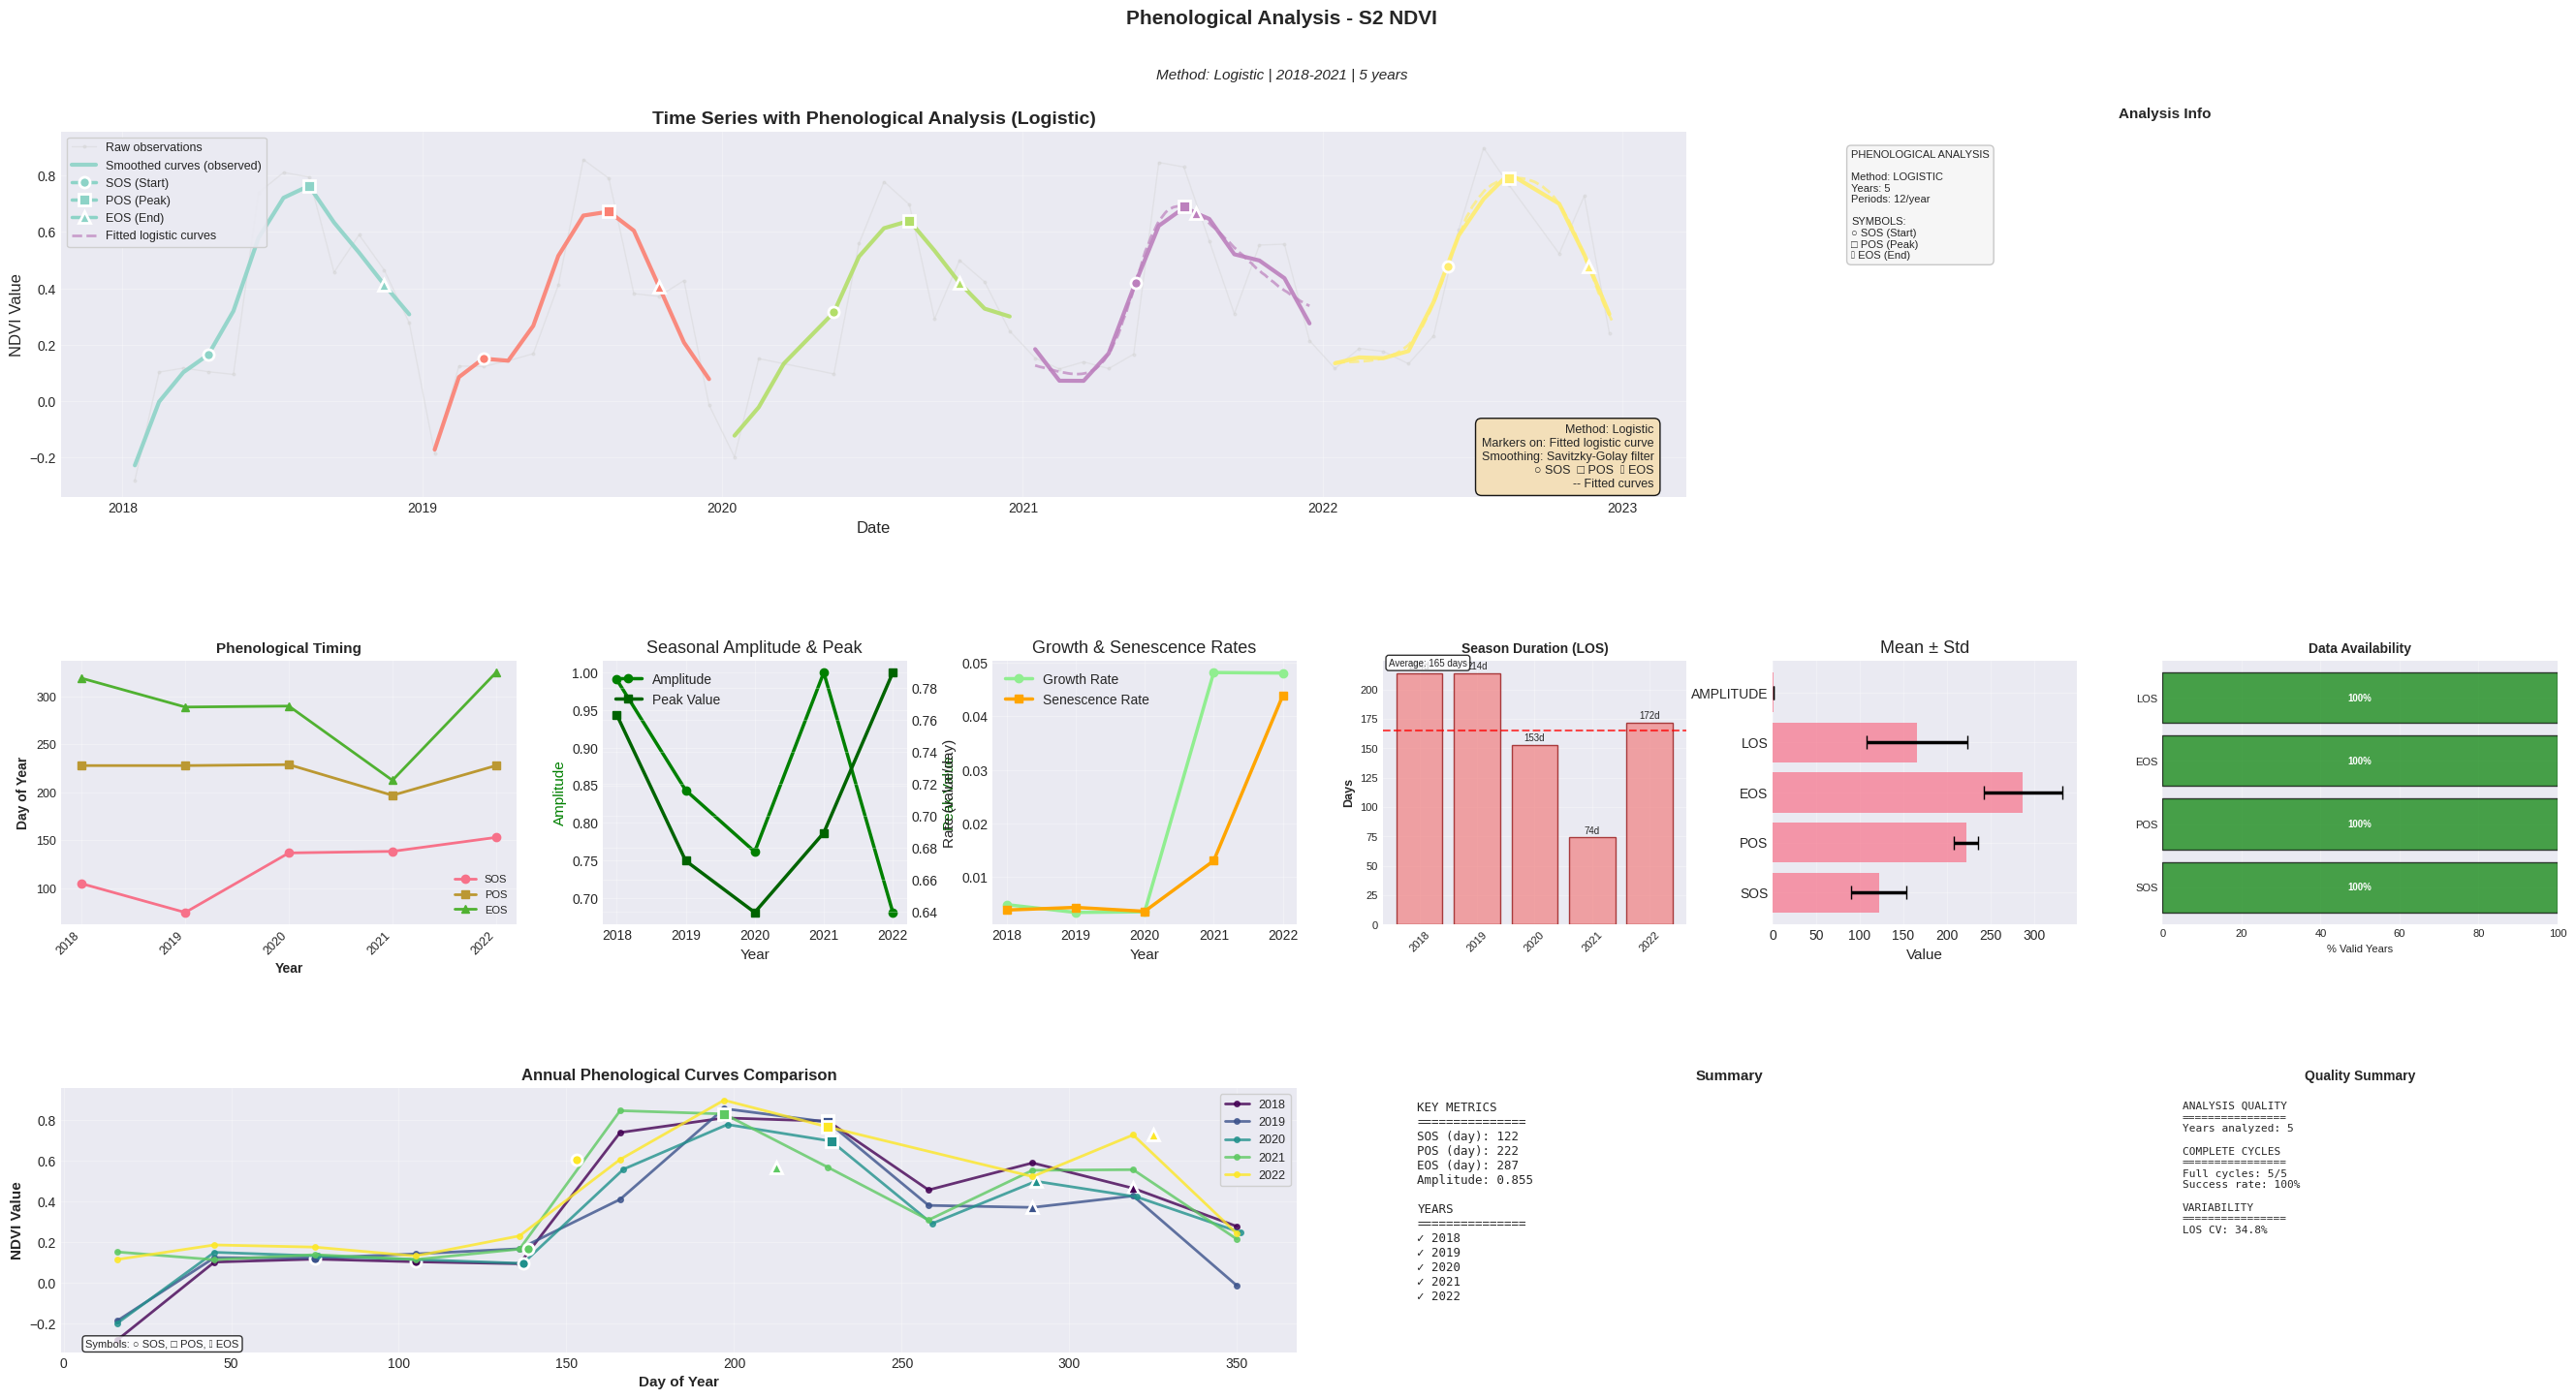

In [5]:
# Full example over the site selected above
import ee
import geemap
import numpy as np
import pandas as pd
from ndvi2gif import NdviSeasonality
from ndvi2gif.timeseries import TimeSeriesAnalyzer

ee.Initialize(project='your-project-id')

processor = NdviSeasonality(
    roi=roi,
    periods=12,
    start_year=2018,
    end_year=2022,
    sat='S2',
    index='ndvi',
    key='median'
)

ts_analyzer = TimeSeriesAnalyzer(processor)

# 1. Comprehensive analysis
fig1 = ts_analyzer.plot_comprehensive_analysis(
    point=point,
    figsize=(24, 16),
    save_path='rice_comprehensive.png'
)

# 2. Phenology, threshold method
fig2 = ts_analyzer.plot_phenology_analysis(
    point=point,
    method='threshold',
    threshold_percentile=40,
    figsize=(28, 18),
    save_path='rice_phenology_threshold.png'
)

# 3. Phenology, derivative method
fig3 = ts_analyzer.plot_phenology_analysis(
    point=point,
    method='derivative',
    figsize=(28, 18),
    save_path='rice_phenology_derivative.png'
)

# 4. Phenology, logistic method
fig4 = ts_analyzer.plot_phenology_analysis(
    point=point,
    method='logistic',
    figsize=(28, 18),
    save_path='rice_phenology_logistic.png'
)

In [6]:
# ========== SMOOTHING IMPACT ==========
comparison = ts_analyzer.compare_smoothing_impact(
    point=point,
    method='threshold', 
    threshold_percentile=40
)

print(comparison['summary'])

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 350.0
EOS found at day 350.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 320.0
EOS found at day 320.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0
Year 2022: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 5/5 (100.0%)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 350.0
EOS found at day 350.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EO

Running smoothing comparison...
Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 350.0
EOS found at day 350.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 320.0
EOS found at day 320.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0
Year 2022: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 5/5 (100.0%)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 350.0
EOS found at day 350.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0
Adaptive thr

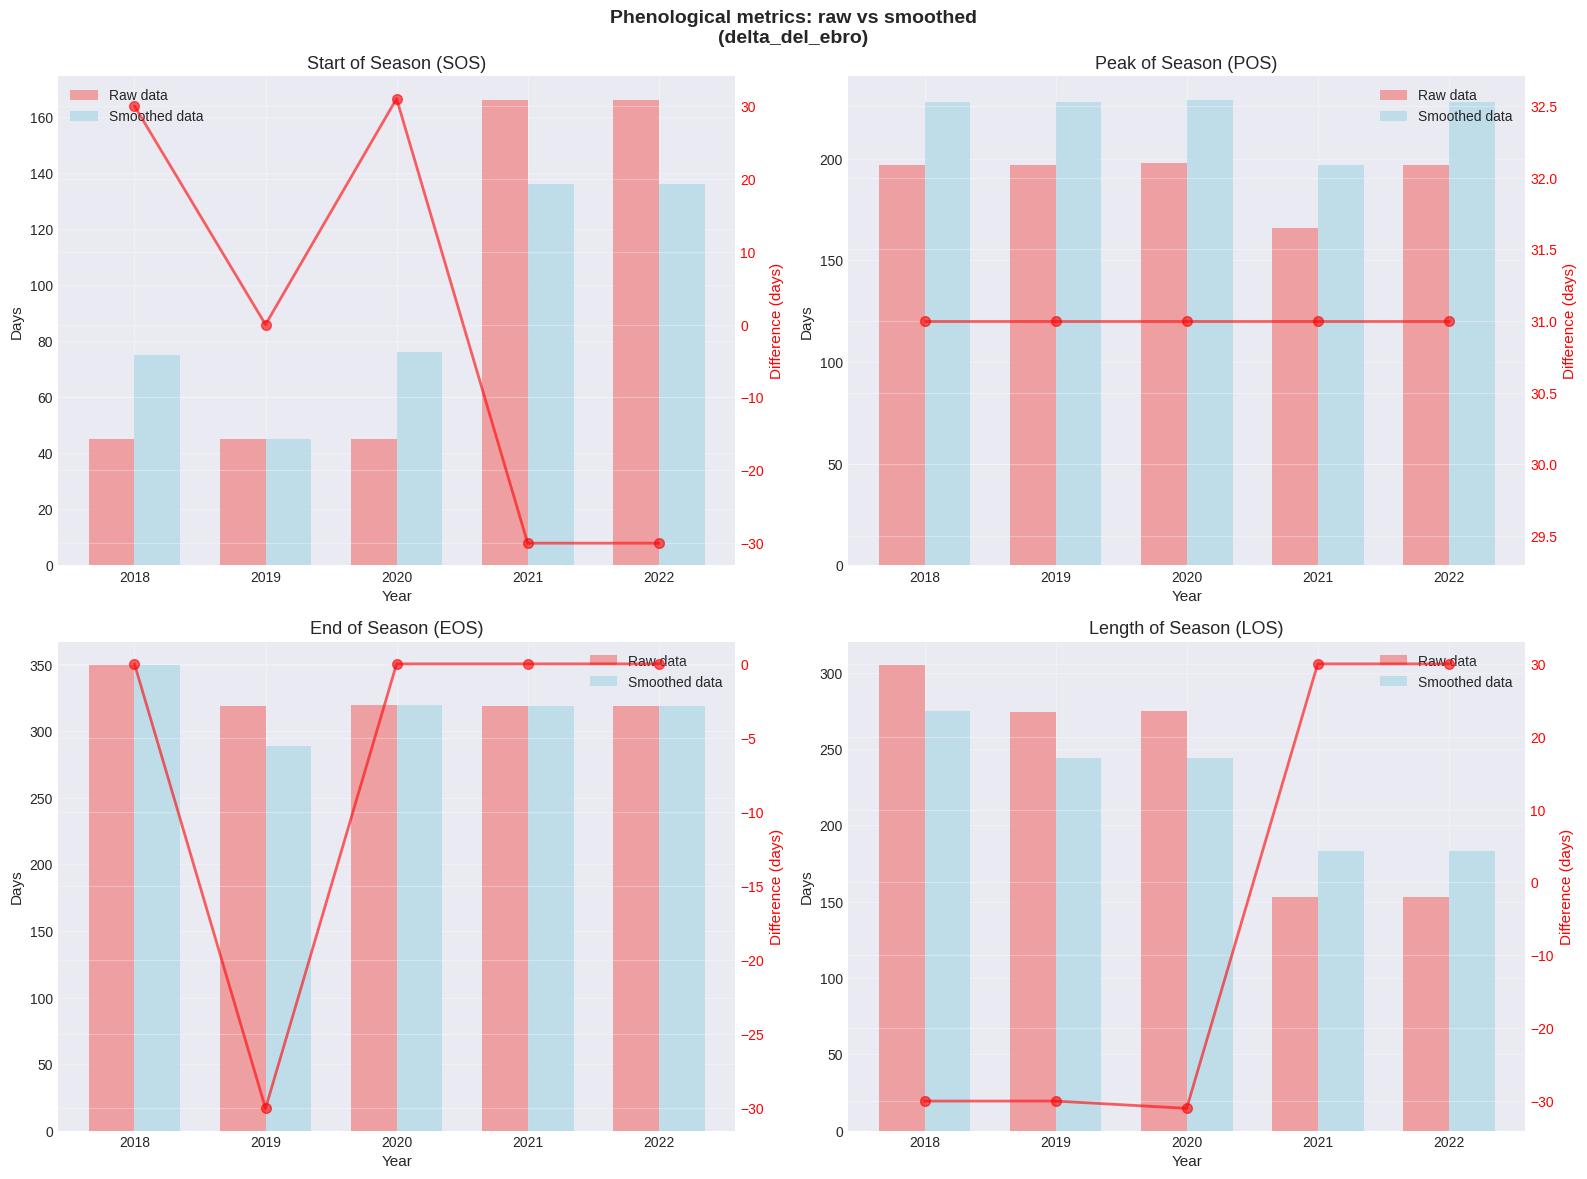


DERIVATIVE METHOD COMPARISON
Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0015, neg=-0.0011
EOS found at day 258.0, 30.0 days after POS
Year 2019: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0014, neg=-0.0012
EOS found at day 258.0, 30.0 days after POS
Year 2020: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0011, neg=-0.0008
EOS found at day 259.0, 30.0 days after POS
Year 2021: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0010
EOS found at day 228.0, 31.0 days after POS
Year 2022: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0011, neg=-0.0011
EOS found at day 289.0, 61.0 days after POS

PHENOLOGY EXTRACTION SUMMARY:
Method: derivative
Success rate: 5/5 (100.0%)
Derivative thresholds: pos=0.0020, neg=-0.0017
EOS found at day 228.0, 31.0 days after POS
Derivative thresholds: pos=0.0019, neg=-0.0019
EOS found at day 228.0, 3

In [7]:
# ========== SMOOTHING IMPACT ==========

# Run the comparison
print("Running smoothing comparison...")
comparison = ts_analyzer.compare_smoothing_impact(
    point=point,
    method='threshold', 
    threshold_percentile=40
)

# Quantitative summary
print("\n" + "="*50)
print("SMOOTHING IMPACT SUMMARY")
print("="*50)
print(comparison['summary'])

# Year-by-year detail
print("\n" + "="*50)
print("DIFFERENCES BY YEAR")
print("="*50)

for year in sorted(comparison['differences'].keys()):
    print(f"\nYEAR {year}:")
    year_diff = comparison['differences'][year]
    
    for metric, data in year_diff.items():
        raw_val = data['raw']
        smooth_val = data['smoothed']
        diff = data['difference']
        rel_change = data['relative_change']
        
        print(f"  {metric.upper():<12}: "
              f"Raw={raw_val:6.1f}, "
              f"Smoothed={smooth_val:6.1f}, "
              f"Diff={diff:+5.1f} days "
              f"({rel_change:+4.1f}%)")

# Aggregated statistics
print("\n" + "="*50) 
print("AGGREGATED STATISTICS")
print("="*50)

all_diffs = {}
for year_data in comparison['differences'].values():
    for metric, data in year_data.items():
        if metric not in all_diffs:
            all_diffs[metric] = []
        if not np.isnan(data['difference']):
            all_diffs[metric].append(data['difference'])

for metric, diffs in all_diffs.items():
    if diffs:
        mean_diff = np.mean(diffs)
        std_diff = np.std(diffs)
        max_abs_diff = np.max(np.abs(diffs))
        
        print(f"{metric.upper():<12}: "
              f"Mean={mean_diff:+5.2f}±{std_diff:4.2f} days, "
              f"Max={max_abs_diff:5.2f} days")

# Comparison figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Phenological metrics: raw vs smoothed\n({site})', 
             fontsize=14, fontweight='bold')

metrics_to_plot = ['sos', 'pos', 'eos', 'los']
metric_labels = ['Start of Season (SOS)', 'Peak of Season (POS)', 
                'End of Season (EOS)', 'Length of Season (LOS)']

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx//2, idx%2]
    
    # Collect the data
    years = []
    raw_vals = []
    smooth_vals = []
    
    for year in sorted(comparison['differences'].keys()):
        if metric in comparison['differences'][year]:
            years.append(year)
            raw_vals.append(comparison['differences'][year][metric]['raw'])
            smooth_vals.append(comparison['differences'][year][metric]['smoothed'])
    
    if years:
        x = np.arange(len(years))
        width = 0.35
        
        # Side-by-side bars
        ax.bar(x - width/2, raw_vals, width, label='Raw data', 
               alpha=0.7, color='lightcoral')
        ax.bar(x + width/2, smooth_vals, width, label='Smoothed data', 
               alpha=0.7, color='lightblue')
        
        # Axis setup
        ax.set_xlabel('Year')
        ax.set_ylabel('Days' if metric != 'los' else 'Days')
        ax.set_title(label)
        ax.set_xticks(x)
        ax.set_xticklabels(years)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Differences as a line
        ax2 = ax.twinx()
        diffs = [smooth_vals[i] - raw_vals[i] for i in range(len(years))]
        ax2.plot(x, diffs, 'ro-', alpha=0.6, linewidth=2, 
                label='Difference (Smoothed - Raw)')
        ax2.set_ylabel('Difference (days)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.savefig('phenology_comparison_raw_vs_smoothed.png', dpi=300, bbox_inches='tight')
plt.show()

# Same comparison with the derivative method
print("\n" + "="*70)
print("DERIVATIVE METHOD COMPARISON")
print("="*70)

comparison_deriv = ts_analyzer.compare_smoothing_impact(
    point=point,
    method='derivative'
)

print(comparison_deriv['summary'])

There we go again...
ERA5-Land daily climate reanalysis (1950-present, ~11km resolution)
Using point coordinates: (-6.48, 37.13)


Extracting 48 temporal periods...



Successfully extracted 48 data points


Using ROI centroid: [-6.4799992863353175, 37.130020517645576]


Extracting 48 temporal periods...



Successfully extracted 48 data points


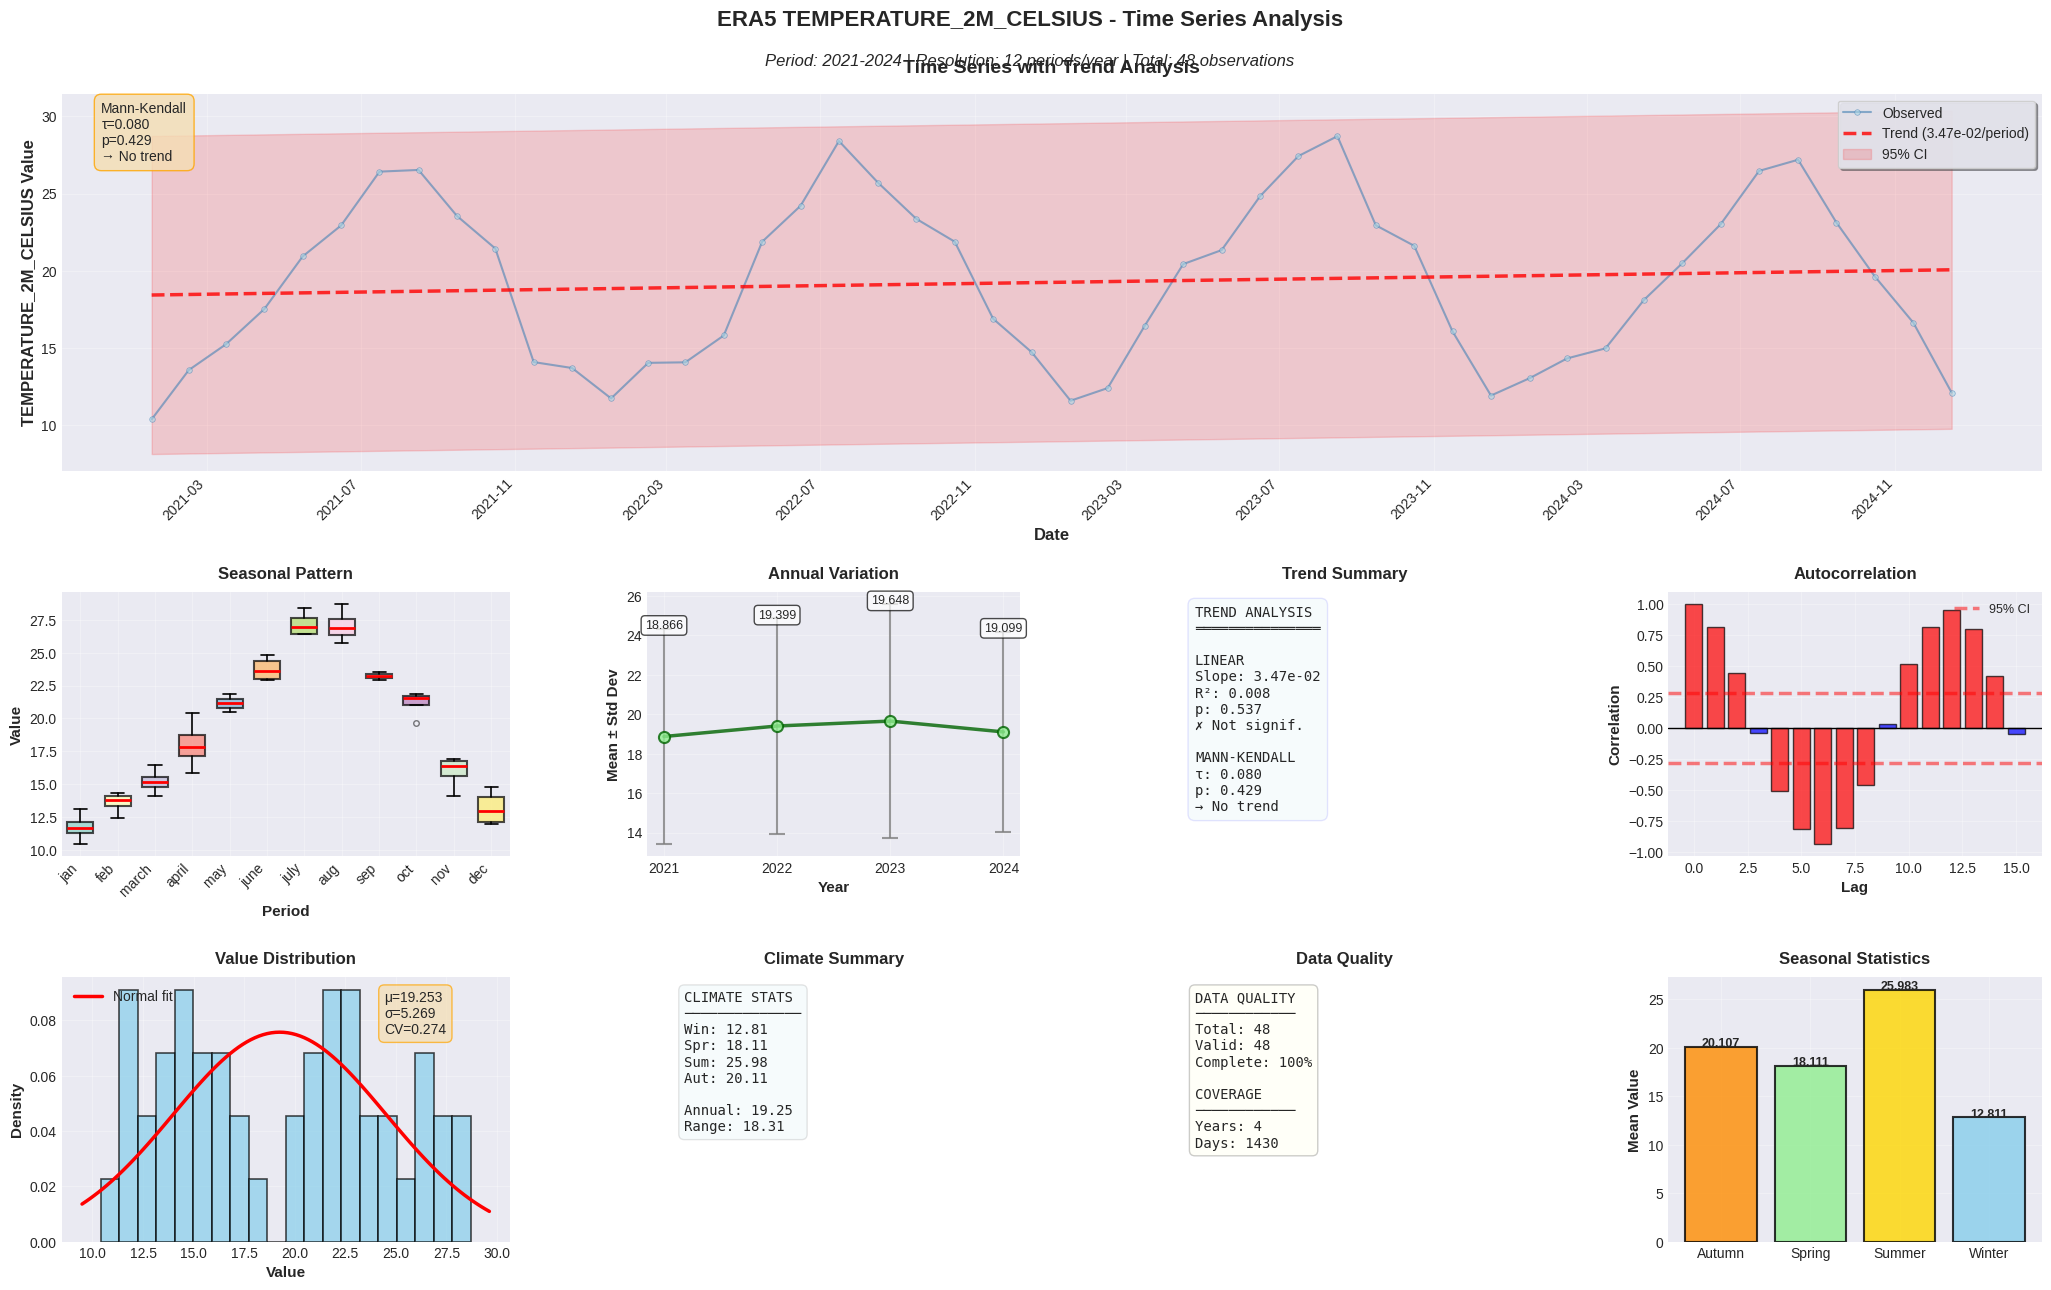

In [8]:
# Temperature analysis (ERA5)
# This example uses its own site, so it needs its own ROI around it
era5_point = (-6.48, 37.13)
era5_roi = ee.Geometry.Point(list(era5_point)).buffer(20000)

temp = NdviSeasonality(
  roi=era5_roi,
  sat='ERA5',
  index='temperature_2m_celsius',
  periods=12,
  start_year=2021,
  end_year=2024,
  key='mean'
)

# Build the analyzer
analyzer = TimeSeriesAnalyzer(temp)

# Extract the time series
df = analyzer.extract_time_series(point=era5_point, scale=11000)

# Trend analysis
trends = analyzer.analyze_trend(df=df, method='all')

# Full visualization
fig = analyzer.plot_comprehensive_analysis()

There we go again...
CHIRPS daily precipitation (1981-present, ~5.5km resolution, 50°S-50°N)
Using ROI centroid: [-6.479999821582292, 37.13000512944234]


Extracting 48 temporal periods...



Successfully extracted 48 data points
Using cached time series data


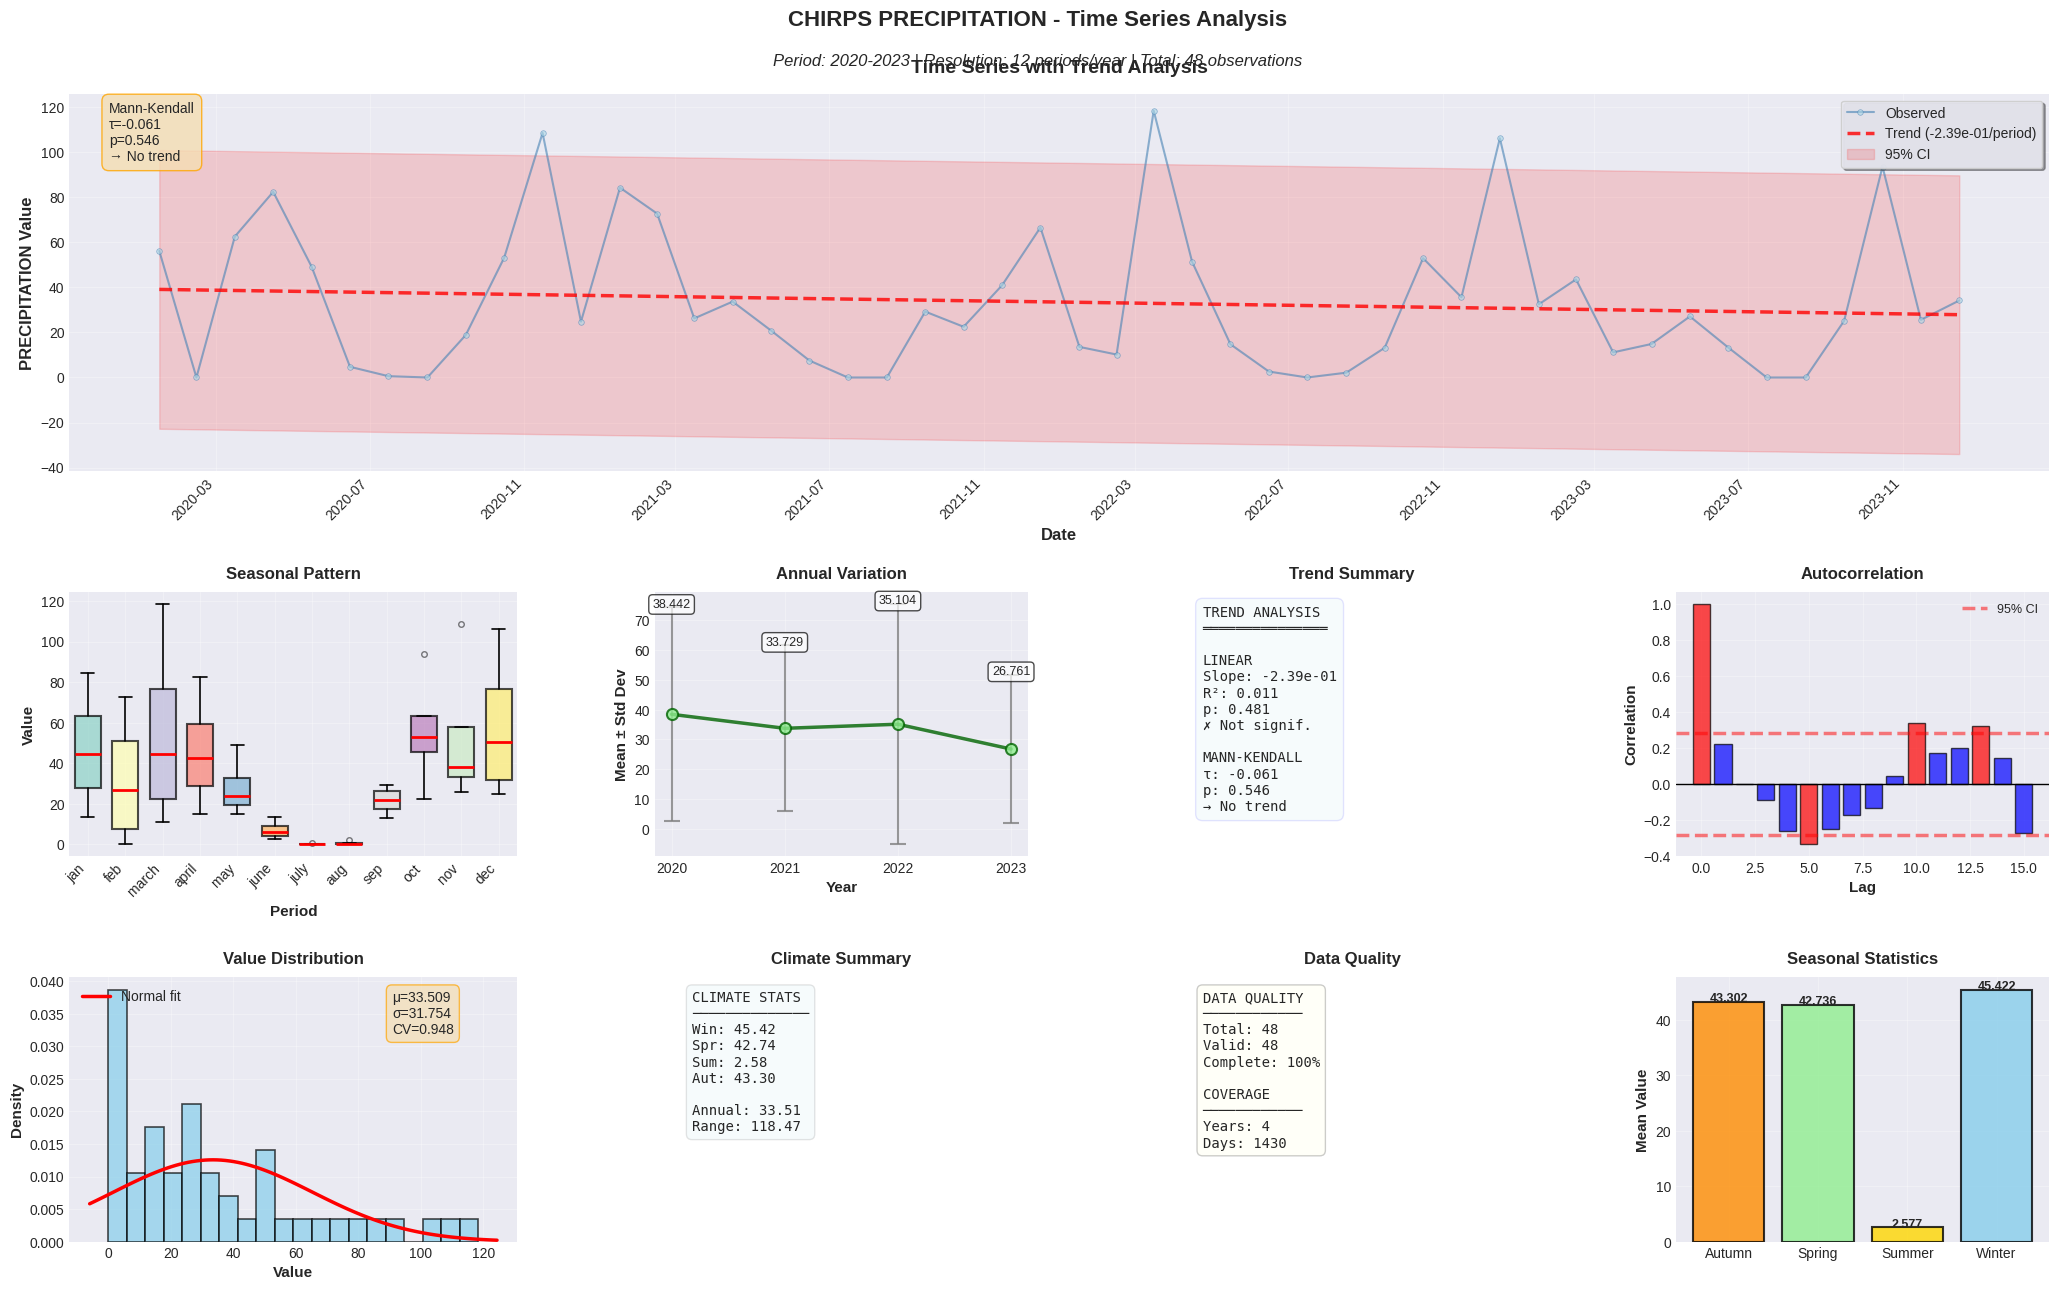

In [9]:
chirps = NdviSeasonality(
  roi=ee.Geometry.Point([-6.48, 37.13]).buffer(5000),
  sat='CHIRPS',
  index='precipitation',
  periods=12,
  start_year=2020,
  end_year=2023,  # inclusive
  key='sum'  # monthly total
)

# Temporal analysis
analyzer = TimeSeriesAnalyzer(chirps)
df = analyzer.extract_time_series()
trends = analyzer.analyze_trend(df=df)
fig = analyzer.plot_comprehensive_analysis()  # shows climate statistics
